# MIT–Stanford Battery Dataset: Batch 1·2·3 EDA

프로젝트 가이드의 5개 질문을 기준으로 작성한 재현 가능한 EDA 노트북입니다.

1. Cycle Life 분포와 이상치
2. 방전용량 열화곡선과 knee point 탐색
3. 초기 ΔQ(V): cycle 100 − cycle 10
4. 충전 조건(C-rate)과 수명의 관계
5. 초기 특징과 Cycle Life의 상관관계·다중공선성

**권장 분할:** Batch 1 학습·검증 → Batch 2 최종 테스트 → Batch 3 추가 외부 검증

## DAY 1 산출 목표

오늘의 목표는 모델을 완성하는 것이 아니라, **EDA 근거로 모델 전략을 확정하는 것**입니다.

1. Batch 1·2·3의 데이터 품질, 수명 분포, 열화곡선, ΔQ(V), 충전조건, 상관관계를 확인합니다.
2. 각 Batch를 개별적으로 요약한 뒤, 동일 축·동일 지표로 배치 간 차이를 비교합니다.
3. `cycle_life` 결측 셀과 이상치를 식별하고 처리 원칙을 정합니다.
4. Regression과 Classification 중 하나를 EDA 근거로 선택하고 Target을 명시합니다.
5. 사용할 초기-cycle 범위, 후보 특징, 데이터 분할, 후보 모델, 평가지표를 설계합니다.
6. 그래프 나열이 아니라 **관찰 → 해석 → 모델링 시사점**의 흐름으로 DAY 1 보고서를 작성합니다.

> 이 노트북은 각 Batch를 따로 보여주는 subplot·group table과 세 Batch를 직접 비교하는 그래프를 함께 사용합니다. 나누어 보는 것과 비교해서 보는 것 둘 다 필요합니다.

## 0. 환경 설정과 원본 파일

MATLAB v7.3(HDF5) 파일 전체를 메모리에 적재하지 않고 필요한 구조만 참조합니다. 원본 파일은 프로젝트의 `data/`, 분석 함수는 `src/battery_eda.py`, 생성 결과는 `results/battery_eda/`를 사용합니다.

In [7]:
import os
import sys
import importlib.util

os.environ.pop("PYTHONPATH", None)

sys.path[:] = [
    path for path in sys.path
    if "Documents/Codex/" not in path
]

print(sys.executable)
print(importlib.util.find_spec("numpy").origin)

/Users/jungseungwoo/Desktop/data-mini-project/.venv/bin/python
/Users/jungseungwoo/Desktop/data-mini-project/.venv/lib/python3.11/site-packages/numpy/__init__.py


In [8]:
import numpy as np

print(np.__version__)
print(np.__file__)

2.4.6
/Users/jungseungwoo/Desktop/data-mini-project/.venv/lib/python3.11/site-packages/numpy/__init__.py


In [9]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """VS Code/Jupyter의 실행 위치가 달라도 프로젝트 루트를 찾습니다."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'data').is_dir() and (candidate / 'src').is_dir():
            return candidate
    raise FileNotFoundError(
        'data-mini-project 루트를 찾지 못했습니다. VS Code에서 data-mini-project 폴더를 열고 실행하세요.'
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'battery_eda'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
from IPython.display import Image, display
import battery_eda as eda

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('PROJECT_ROOT:', PROJECT_ROOT)
for batch, file_path in eda.FILES.items():
    if not file_path.exists():
        raise FileNotFoundError(f'{batch} 파일이 없습니다: {file_path}')
    print(f'{batch}: {file_path.relative_to(PROJECT_ROOT)} | {file_path.stat().st_size / (1024**3):.2f} GB')

PROJECT_ROOT: /Users/jungseungwoo/Desktop/data-mini-project
Batch 1: data/2017-05-12_batchdata_updated_struct_errorcorrect.mat | 2.82 GB
Batch 2: data/2018-02-20_batchdata_updated_struct_errorcorrect.mat | 1.88 GB
Batch 3: data/2018-04-12_batchdata_updated_struct_errorcorrect.mat | 3.01 GB


### 셀 단위 특징 추출

모델 입력 후보는 초기 100사이클까지만 사용합니다. `cycle_life`는 정답·평가용으로만 유지합니다.

In [10]:
frames, degradation, delta_curves = [], [], []
for batch, path in eda.FILES.items():
    frame, deg, delta = eda.extract_batch(batch, path)
    frames.append(frame)
    degradation.extend(deg)
    delta_curves.extend(delta)

df = pd.concat(frames, ignore_index=True)
labeled = df.dropna(subset=['cycle_life']).copy()
summary = eda.batch_summary(df)
print(f'원본 셀: {len(df)}, cycle_life 라벨 보유 셀: {len(labeled)}')
display(summary)

원본 셀: 139, cycle_life 라벨 보유 셀: 129


,batch,raw_cells,labeled_cells,min_life,median_life,mean_life,max_life,std_life,short_lt500,long_gt1000,class1_ge550,policies,knee_fraction_median
0,Batch 1,46,46,534.000,858.500,844.717,"1,227.000",184.629,0,10,45.000,23,0.674
1,Batch 2,47,39,392.000,472.000,565.744,"1,186.000",222.202,28,3,9.000,20,0.558
2,Batch 3,46,44,541.000,"1,005.500","1,059.659","1,935.000",313.870,0,23,43.000,8,0.829


### 데이터 품질 확인

`cycle_life`가 없는 셀은 수명 통계·상관·분류 라벨에서 제외하고 임의 보간하지 않습니다. 원본 열화곡선 확인에는 남겨둡니다.

In [11]:
unlabeled = df[df['cycle_life'].isna()].copy()
print('배치별 라벨 누락 수')
display(unlabeled.groupby('batch').size().rename('missing_cycle_life').to_frame())
display(unlabeled[['batch', 'cell_id', 'policy', 'summary_cycles', 'Qd_100']])

배치별 라벨 누락 수


,missing_cycle_life
batch,
Batch 2,8
Batch 3,2


,batch,cell_id,policy,summary_cycles,Qd_100
68,Batch 2,b2c22,VARCHARGE_2C_100CYCLES,920,1.084
69,Batch 2,b2c23,VARCHARGE_4C_100CYCLES,1152,1.075
81,Batch 2,b2c35,VARCHARGE_6C_100CYCLES,423,1.030
82,Batch 2,b2c36,VARCHARGE_8C_100CYCLES,280,1.003
83,Batch 2,b2c37,3_6C_80PER_3_6C_SLOWCYCLE,101,2.167
84,Batch 2,b2c38,4_8C_80PER_4_8C_SLOWCYCLE,101,2.162
85,Batch 2,b2c39,3_6C_9PER_5C_SLOWCYCLE,434,2.127
86,Batch 2,b2c40,5_2C_58PER_4C_SLOWCYCLE,459,2.162
116,Batch 3,b3c23,4_8C_80PER_4_8C_NEWSTRUCTURE,2189,1.067
125,Batch 3,b3c32,4_8C_80PER_4_8C_NEWSTRUCTURE,2237,1.073


## 1. Cycle Life 분포는 어떻게 생겼는가?

- 단수명: 500사이클 미만
- 장수명: 1,000사이클 초과
- 분류 라벨: 550사이클 이상을 1로 정의
- 배치 내부 IQR 기준 이상치와 배치 간 분포 차이를 함께 확인합니다.

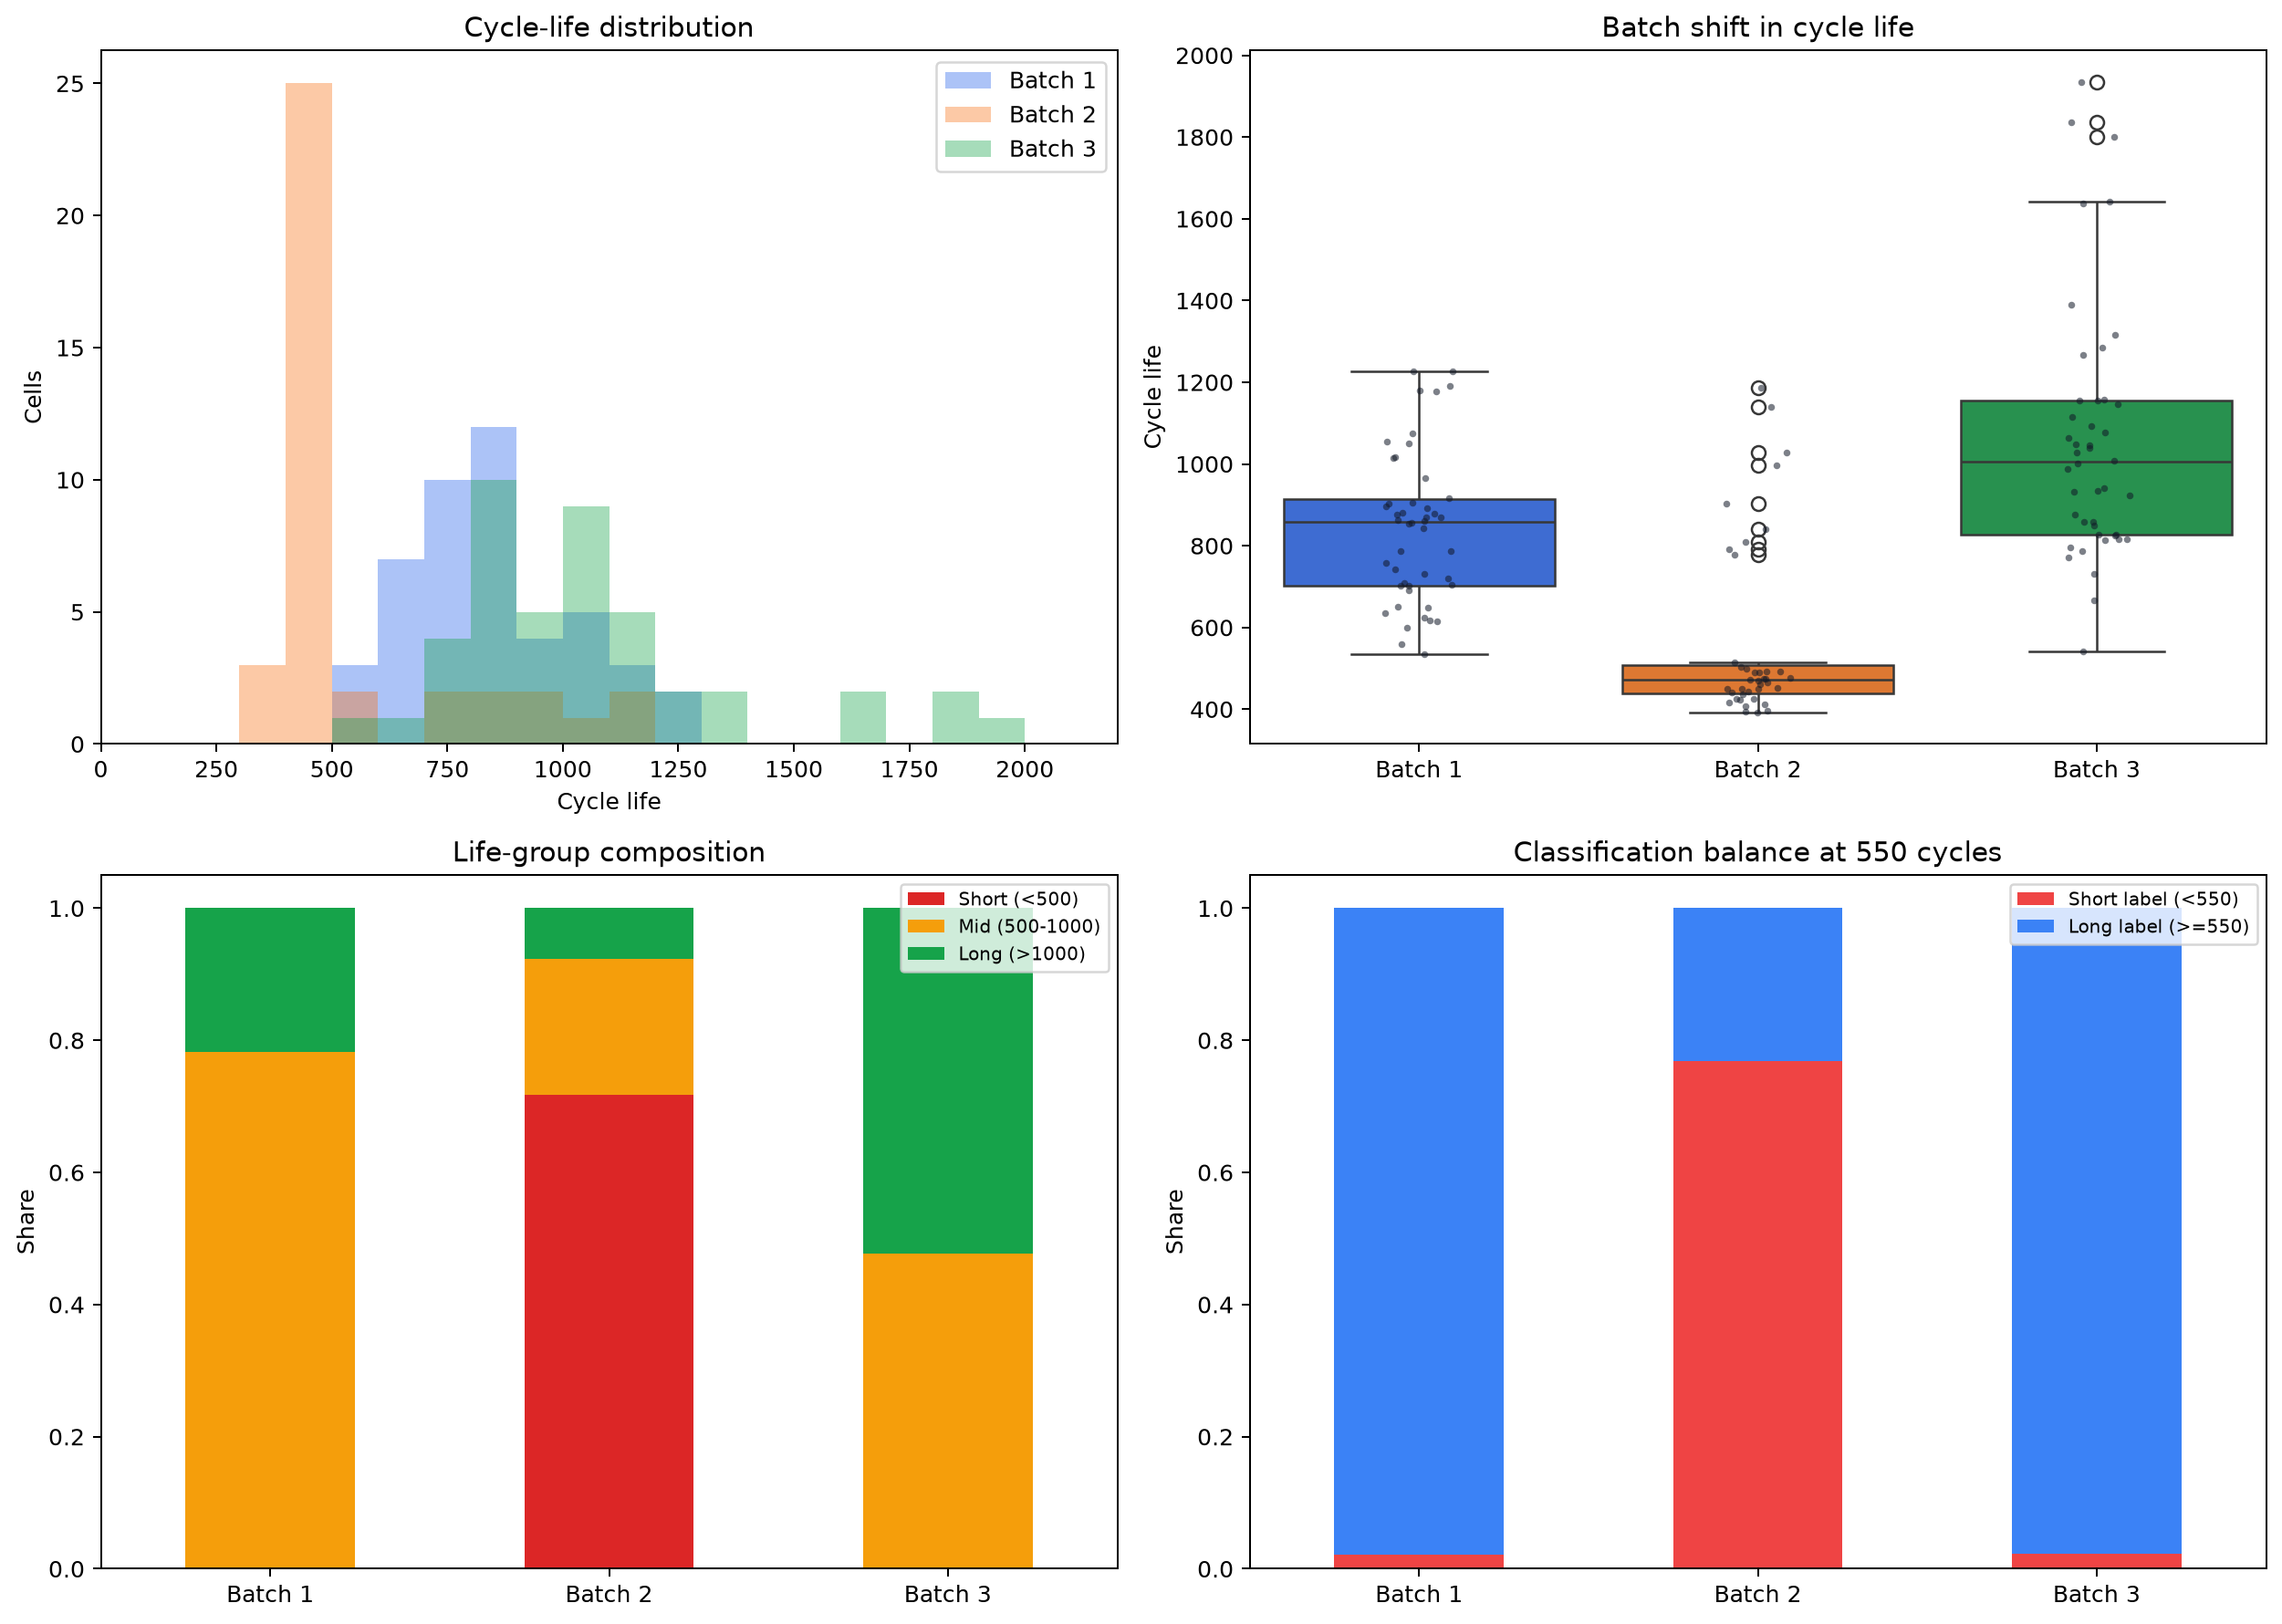

,labeled_cells,long_550,long_550_ratio,short_lt500,long_gt1000
batch,,,,,
Batch 1,46,45.000,0.978,0,10
Batch 2,39,9.000,0.231,28,3
Batch 3,44,43.000,0.977,0,23


,comparison,median_gap,KS_stat,KS_p,Mann_Whitney_p
0,Batch 1 vs Batch 2,-386.500,0.769,0.000,0.000
1,Batch 1 vs Batch 3,147.000,0.397,0.001,0.001
2,Batch 2 vs Batch 3,533.500,0.769,0.000,0.000


,batch,cell_id,cycle_life,policy,IQR_rule
0,Batch 2,b2c7,777.000,4_8C_80PER_4_8C_NEWSTRUCTURE,high
1,Batch 2,b2c8,904.000,5_2C_58PER_4C_NEWSTRUCTURE,high
2,Batch 2,b2c9,791.000,5_6C_26PER_4_5C_NEWSTRUCTURE,high
3,Batch 2,b2c32,809.000,4_8C_80PER_4_8C_NEWSTRUCTURE,high
4,Batch 2,b2c33,"1,140.000",5_2C_58PER_4C_NEWSTRUCTURE,high
5,Batch 2,b2c34,"1,186.000",5_6C_26PER_4_5C_NEWSTRUCTURE,high
6,Batch 2,b2c43,"1,029.000",4_8C_80PER_4_8C_NEWSTRUCTURE,high
7,Batch 2,b2c44,841.000,5_2C_58PER_4C_NEWSTRUCTURE,high
8,Batch 2,b2c45,997.000,5_6C_26PER_4_5C_NEWSTRUCTURE,high
9,Batch 3,b3c7,"1,836.000",4_8C_80PER_4_8C_NEWSTRUCTURE,high


In [12]:
life_fig = eda.plot_life_distribution(df)
display(Image(filename=str(life_fig)))

class_balance = labeled.groupby('batch').agg(
    labeled_cells=('cell_id', 'size'),
    long_550=('label_550', 'sum'),
    long_550_ratio=('label_550', 'mean'),
    short_lt500=('cycle_life', lambda s: (s < 500).sum()),
    long_gt1000=('cycle_life', lambda s: (s > 1000).sum()),
)
display(class_balance)
display(eda.ks_table(df))
display(eda.outlier_table(df))

**해석**

- 수명 중앙값은 Batch 1 858.5, Batch 2 472.0, Batch 3 1005.5사이클로 차이가 큽니다.
- 550사이클 기준 장수명 비율은 Batch 1 97.8%, Batch 2 23.1%, Batch 3 97.7%입니다.
- Batch 1에는 음성 클래스가 1개뿐이라, Batch 1 학습을 고정하면 binary classification은 매우 불안정합니다. **이 데이터 분할에서는 회귀가 더 타당합니다.**
- 배치를 합쳐 random split하면 batch 차이를 학습해 성능이 부풀 수 있습니다.

## 2. 방전 용량은 어떻게 감소하는가?

셀별 `QDischarge`와 수명 정규화 곡선을 비교하고, 평활화한 곡선의 최대 음의 곡률 위치를 탐색적 knee proxy로 사용합니다. 운영용 knee 검출기로 확정한 값은 아닙니다.

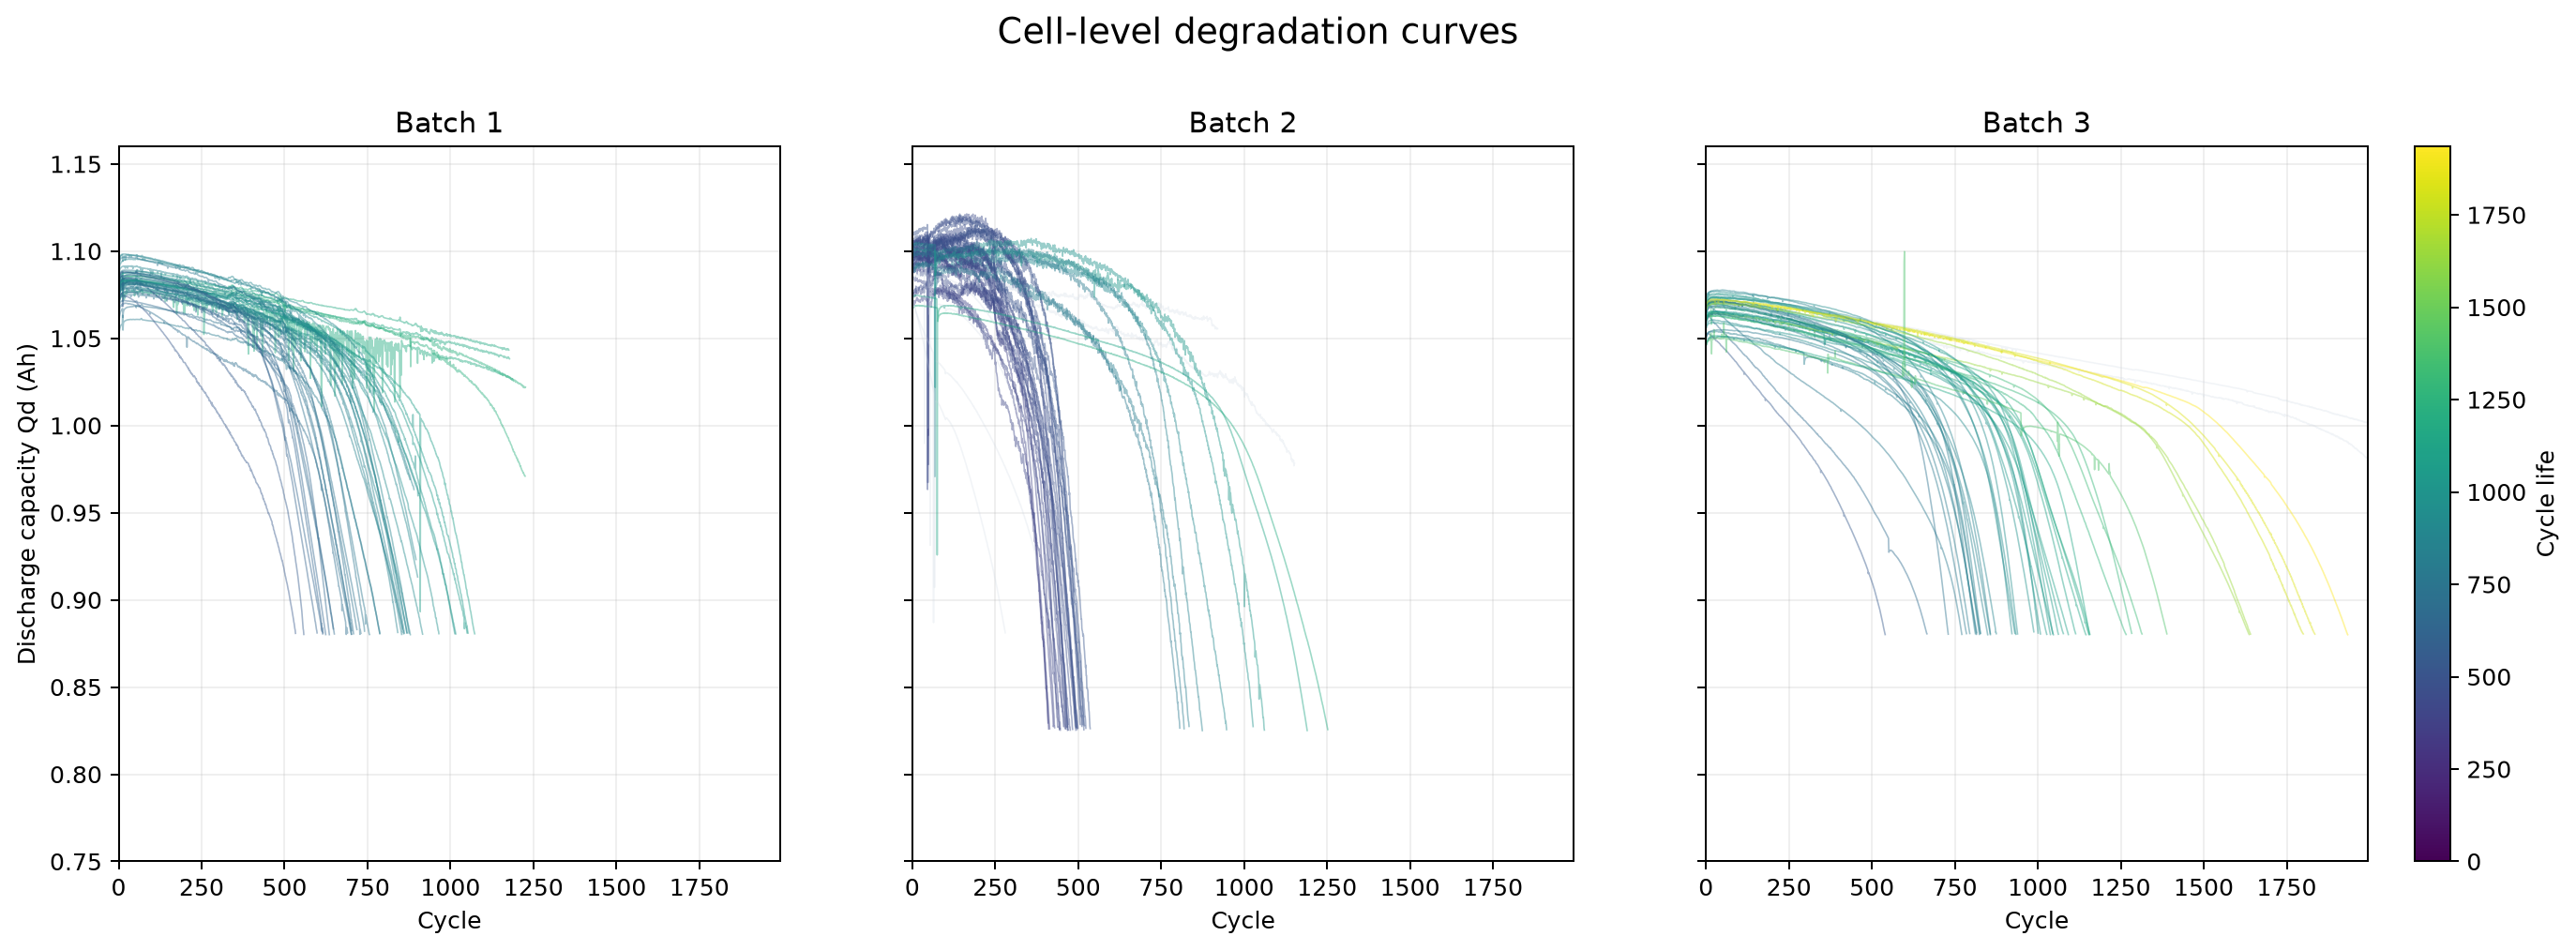

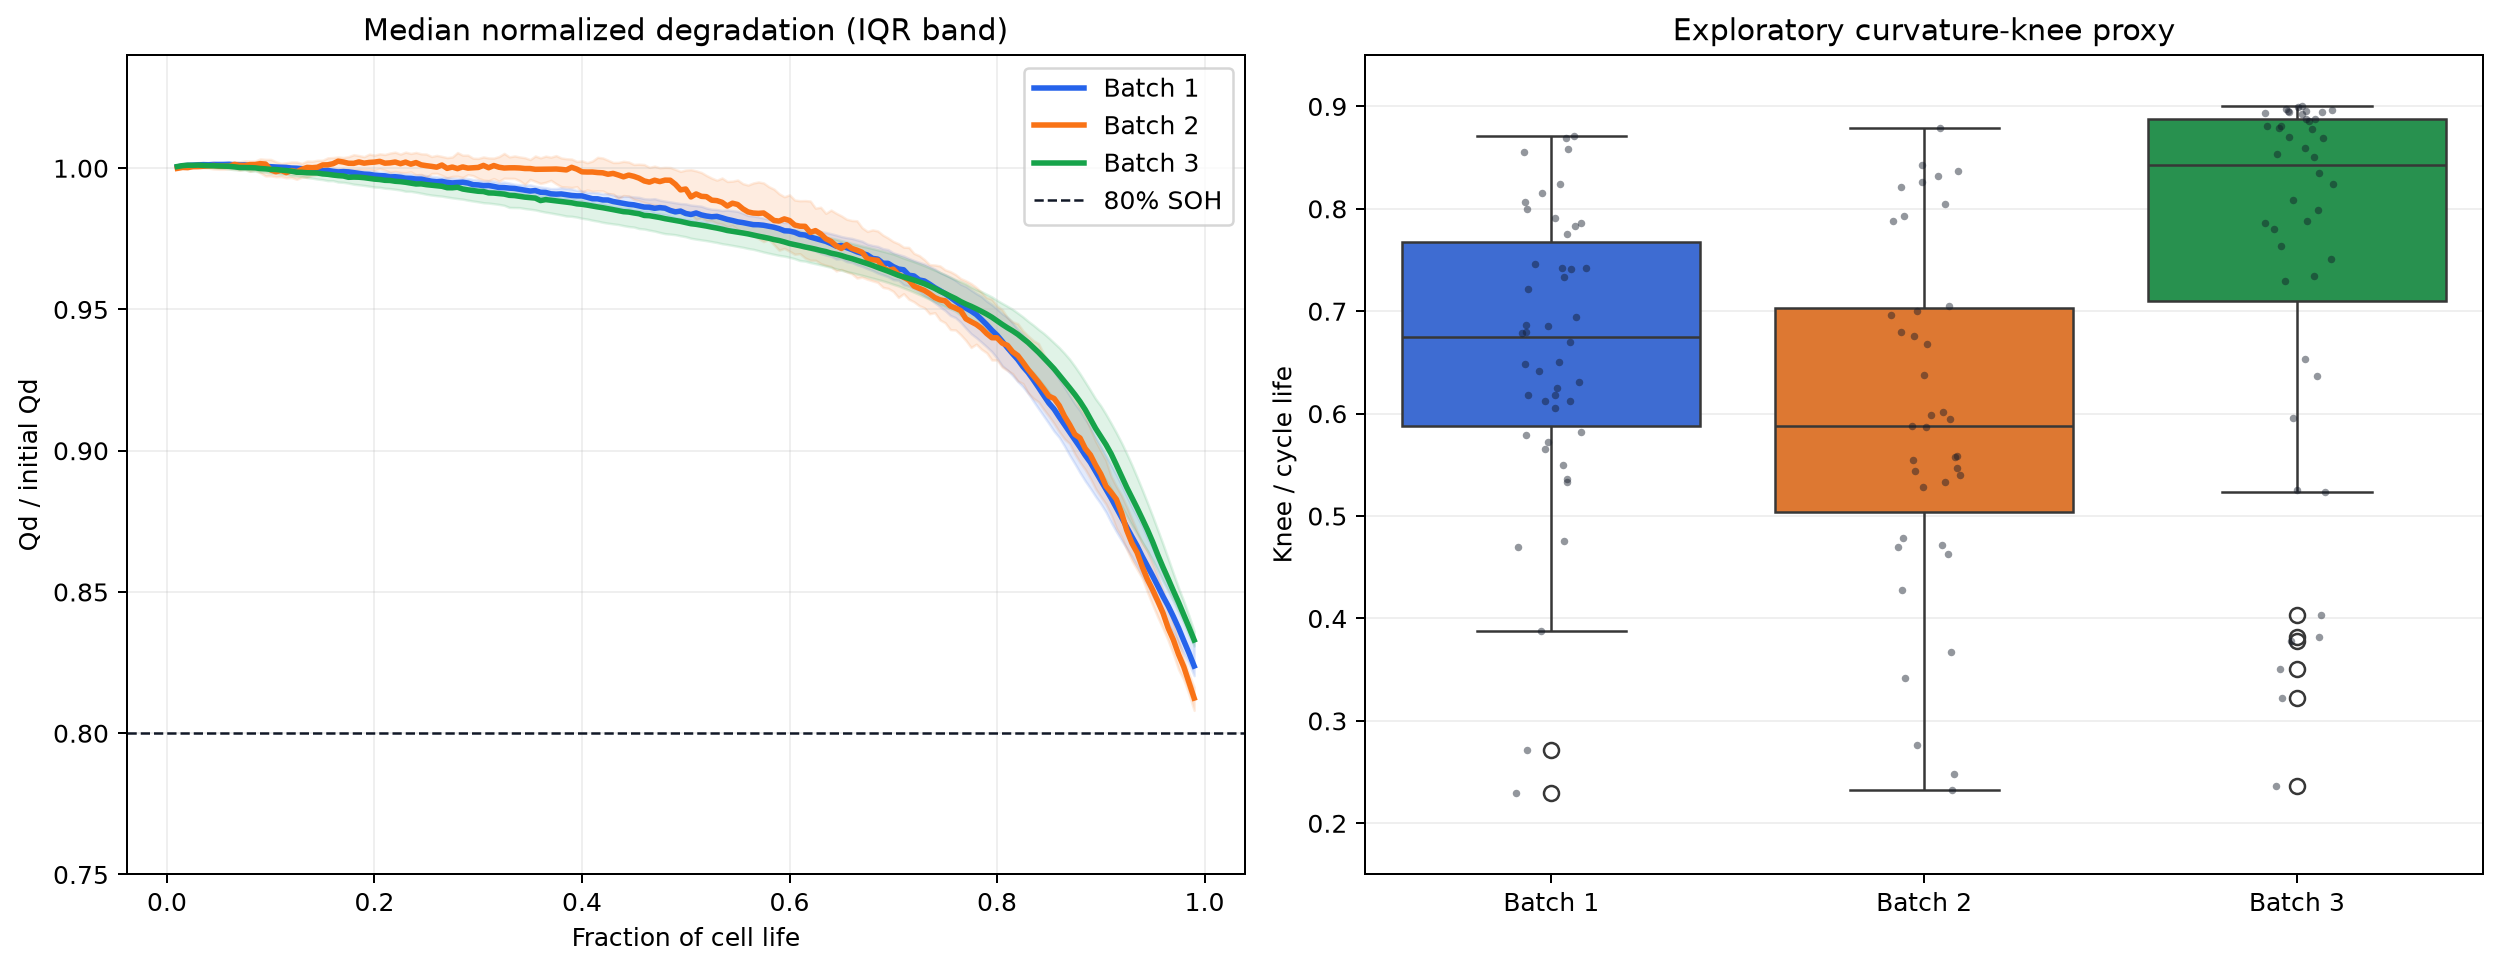

,median,mean,std
batch,,,
Batch 1,0.674,0.660,0.143
Batch 2,0.588,0.597,0.171
Batch 3,0.843,0.751,0.191


In [13]:
degradation_fig = eda.plot_degradation(degradation)
normalized_fig = eda.plot_normalized_degradation(degradation, df)
display(Image(filename=str(degradation_fig)))
display(Image(filename=str(normalized_fig)))

display(labeled.groupby('batch')['knee_fraction_proxy'].agg(['median', 'mean', 'std']))

**해석**

- 셀별 EOL 도달 시점의 분산이 크며 후반부에 열화가 가속되는 비선형 패턴이 나타납니다.
- knee proxy의 수명 대비 중앙 위치는 Batch 1 약 0.67, Batch 2 약 0.56, Batch 3 약 0.83입니다. Batch별 열화 형상 차이도 외부 일반화 성능에 영향을 줄 수 있습니다.

## 3. ΔQ(V) 곡선에서 초기 차이가 보이는가?

`Qdlin(cycle 100) − Qdlin(cycle 10)`의 곡선, 최솟값, 분산, 왜도, 첨도 등을 비교합니다.

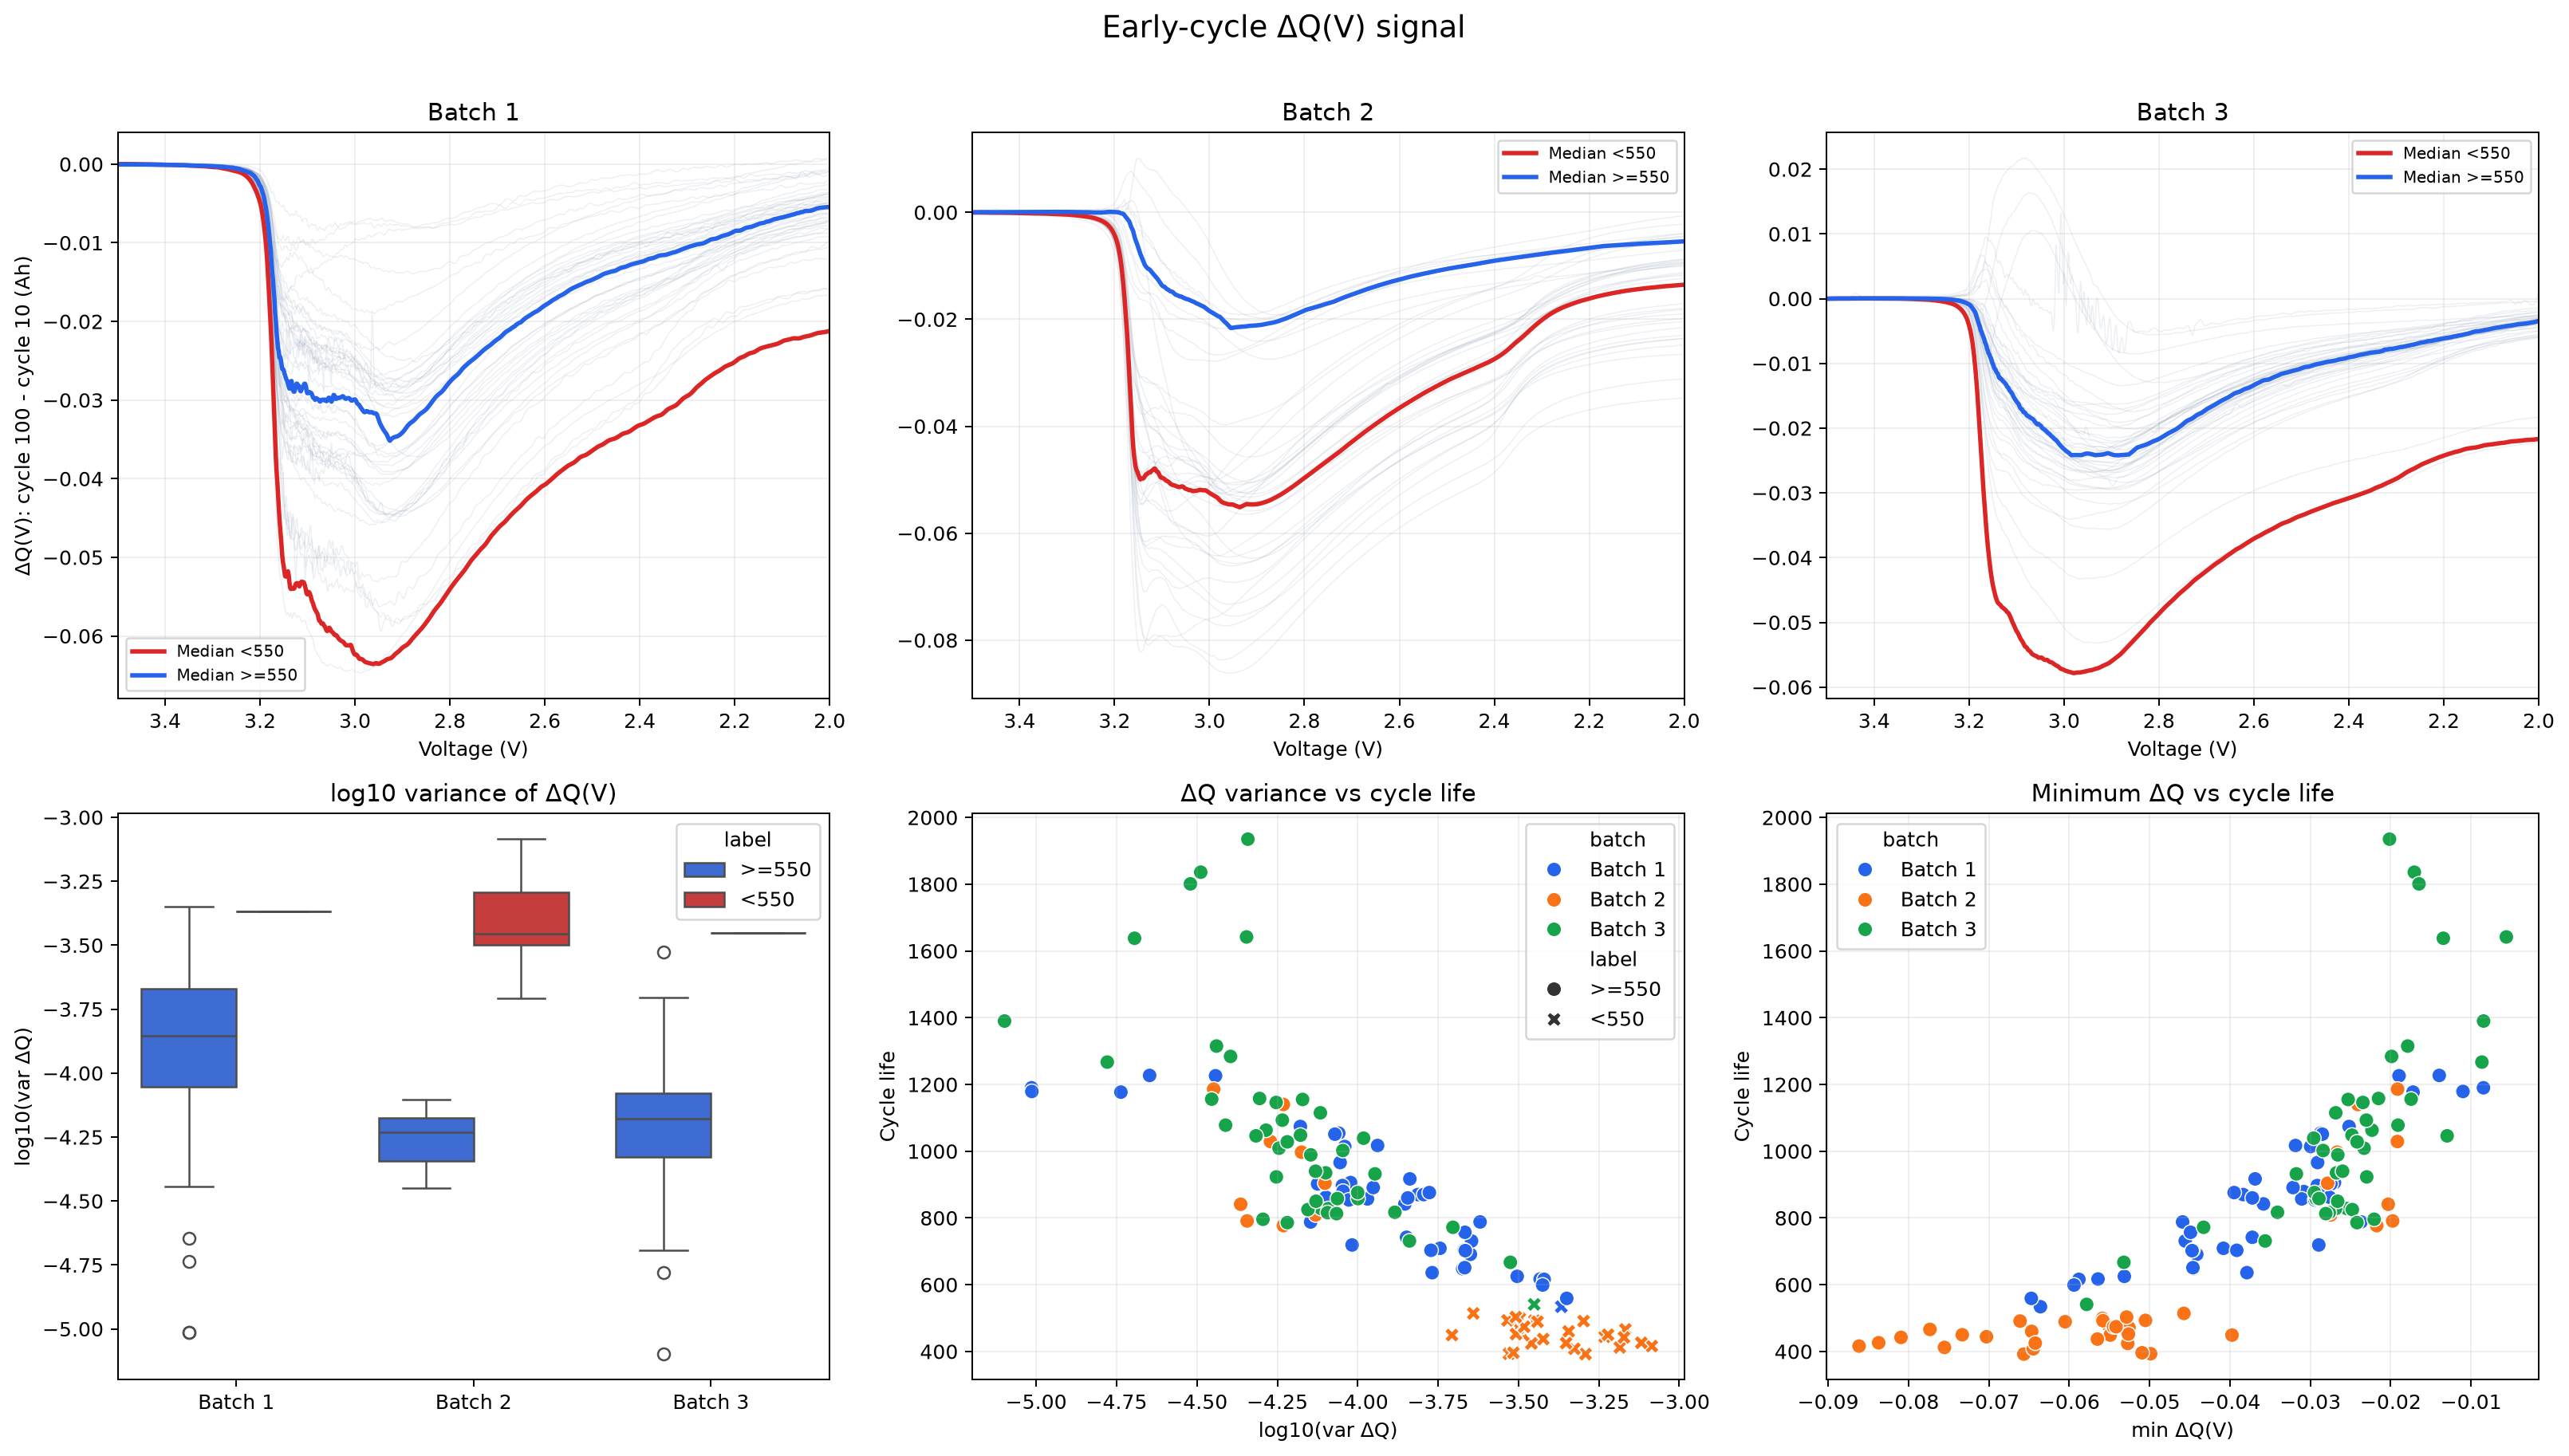

,feature,spearman_rho,spearman_p,pearson_r,n
15,deltaQ_logvar,-0.892,0.000,-0.851,129
11,deltaQ_min,0.883,0.000,0.827,129
13,deltaQ_abs_mean,-0.870,0.000,-0.792,129
12,deltaQ_mean,0.869,0.000,0.797,129
14,deltaQ_range,-0.868,0.000,-0.800,129
0,Qd_mean_2_10,-0.523,0.000,-0.518,129
1,Qd_100,-0.484,0.000,-0.471,129
17,deltaQ_kurtosis,0.377,0.000,0.365,129
16,deltaQ_skew,-0.337,0.000,-0.026,129
4,IR_mean_2_100,-0.314,0.000,0.001,129


In [14]:
delta_fig = eda.plot_deltaq(delta_curves, df)
display(Image(filename=str(delta_fig)))

corr_long = eda.correlation_table(df)
top_corr = (corr_long[corr_long['scope'].eq('All')]
            .dropna(subset=['spearman_rho'])
            .assign(abs_rho=lambda x: x['spearman_rho'].abs())
            .nlargest(10, 'abs_rho'))
display(top_corr[['feature', 'spearman_rho', 'spearman_p', 'pearson_r', 'n']])

**해석**

- `deltaQ_logvar`와 Cycle Life의 전체 Spearman 상관은 약 −0.89입니다.
- 배치별 상관도 Batch 1 −0.87, Batch 2 −0.71, Batch 3 −0.80으로 일관된 방향입니다.
- ΔQ(V)는 회귀 모델의 핵심 후보지만, 전처리와 변수 선택은 반드시 Batch 1 train에서만 학습해야 합니다.

## 4. 충전 조건(C-rate)과 수명의 관계는?

1단계 C-rate, 전환 SOC, 2단계 C-rate와 수명을 비교합니다. `VARCHARGE` 정책은 고정 2-step C-rate로 파싱하지 않지만 다른 EDA에는 포함됩니다.

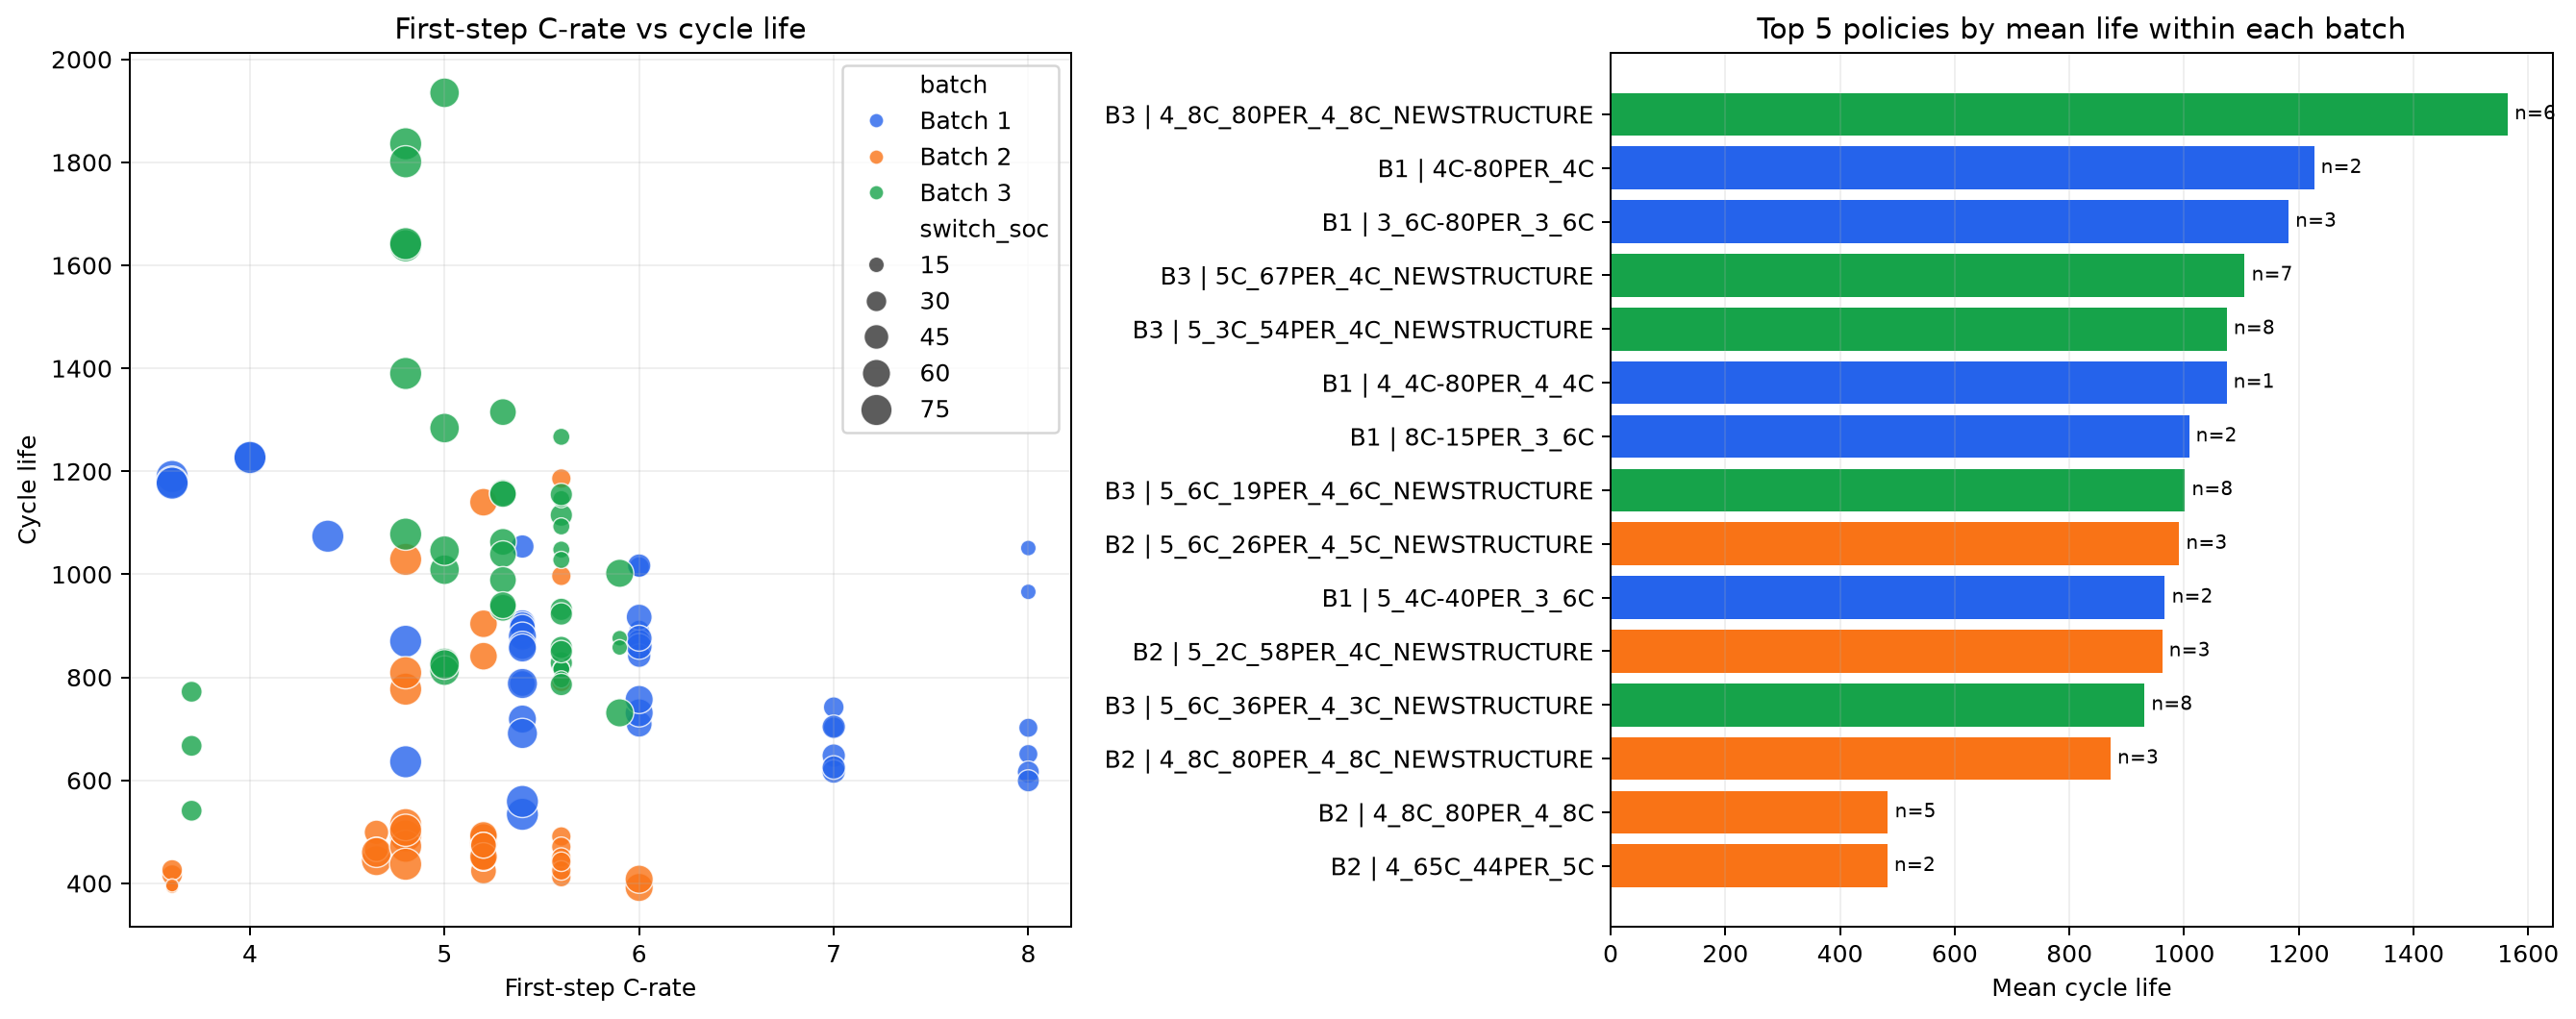

,condition,spearman_rho,p_value,n
0,c_rate_1,-0.027,0.757,129
1,switch_soc,0.160,0.069,129
2,c_rate_2,-0.146,0.099,129


,batch,policy,n,mean_life,median_life
1,Batch 1,4C-80PER_4C,2,"1,226.500","1,226.500"
0,Batch 1,3_6C-80PER_3_6C,3,"1,182.000","1,179.000"
2,Batch 1,4_4C-80PER_4_4C,1,"1,074.000","1,074.000"
20,Batch 1,8C-15PER_3_6C,2,"1,008.500","1,008.500"
4,Batch 1,5_4C-40PER_3_6C,2,966.500,966.500
33,Batch 2,5_6C_26PER_4_5C_NEWSTRUCTURE,3,991.333,997.000
31,Batch 2,5_2C_58PER_4C_NEWSTRUCTURE,3,961.667,904.000
28,Batch 2,4_8C_80PER_4_8C_NEWSTRUCTURE,3,871.667,809.000
27,Batch 2,4_8C_80PER_4_8C,5,483.600,492.000
25,Batch 2,4_65C_44PER_5C,2,482.500,482.500


In [15]:
policy_fig = eda.plot_policy(df)
display(Image(filename=str(policy_fig)))

policy_numeric = labeled.dropna(subset=['c_rate_1', 'switch_soc', 'c_rate_2'])
rows = []
for feature in ['c_rate_1', 'switch_soc', 'c_rate_2']:
    rho, p = eda.stats.spearmanr(policy_numeric[feature], policy_numeric['cycle_life'])
    rows.append({'condition': feature, 'spearman_rho': rho, 'p_value': p, 'n': len(policy_numeric)})
display(pd.DataFrame(rows))

policy_stats = (labeled.groupby(['batch', 'policy'], as_index=False)
                .agg(n=('cycle_life', 'size'), mean_life=('cycle_life', 'mean'), median_life=('cycle_life', 'median'))
                .sort_values(['batch', 'mean_life'], ascending=[True, False]))
display(policy_stats.groupby('batch', group_keys=False).head(5))

**해석**

- 고속 충전 여부 하나만으로 수명이 결정되지 않습니다. 1·2단계 C-rate, 전환 SOC, 셀 구조와 batch가 함께 얽혀 있습니다.
- 프로토콜당 표본이 적은 경우가 많아 평균 수명 순위를 인과적인 최적 충전정책으로 해석하면 안 됩니다.

## 5. 어떤 초기 특징이 수명과 연관되어 있는가?

전체 상관과 배치별 상관을 함께 확인합니다. pooled 상관만 사용하면 batch shift로 인해 Simpson's paradox가 생길 수 있습니다.

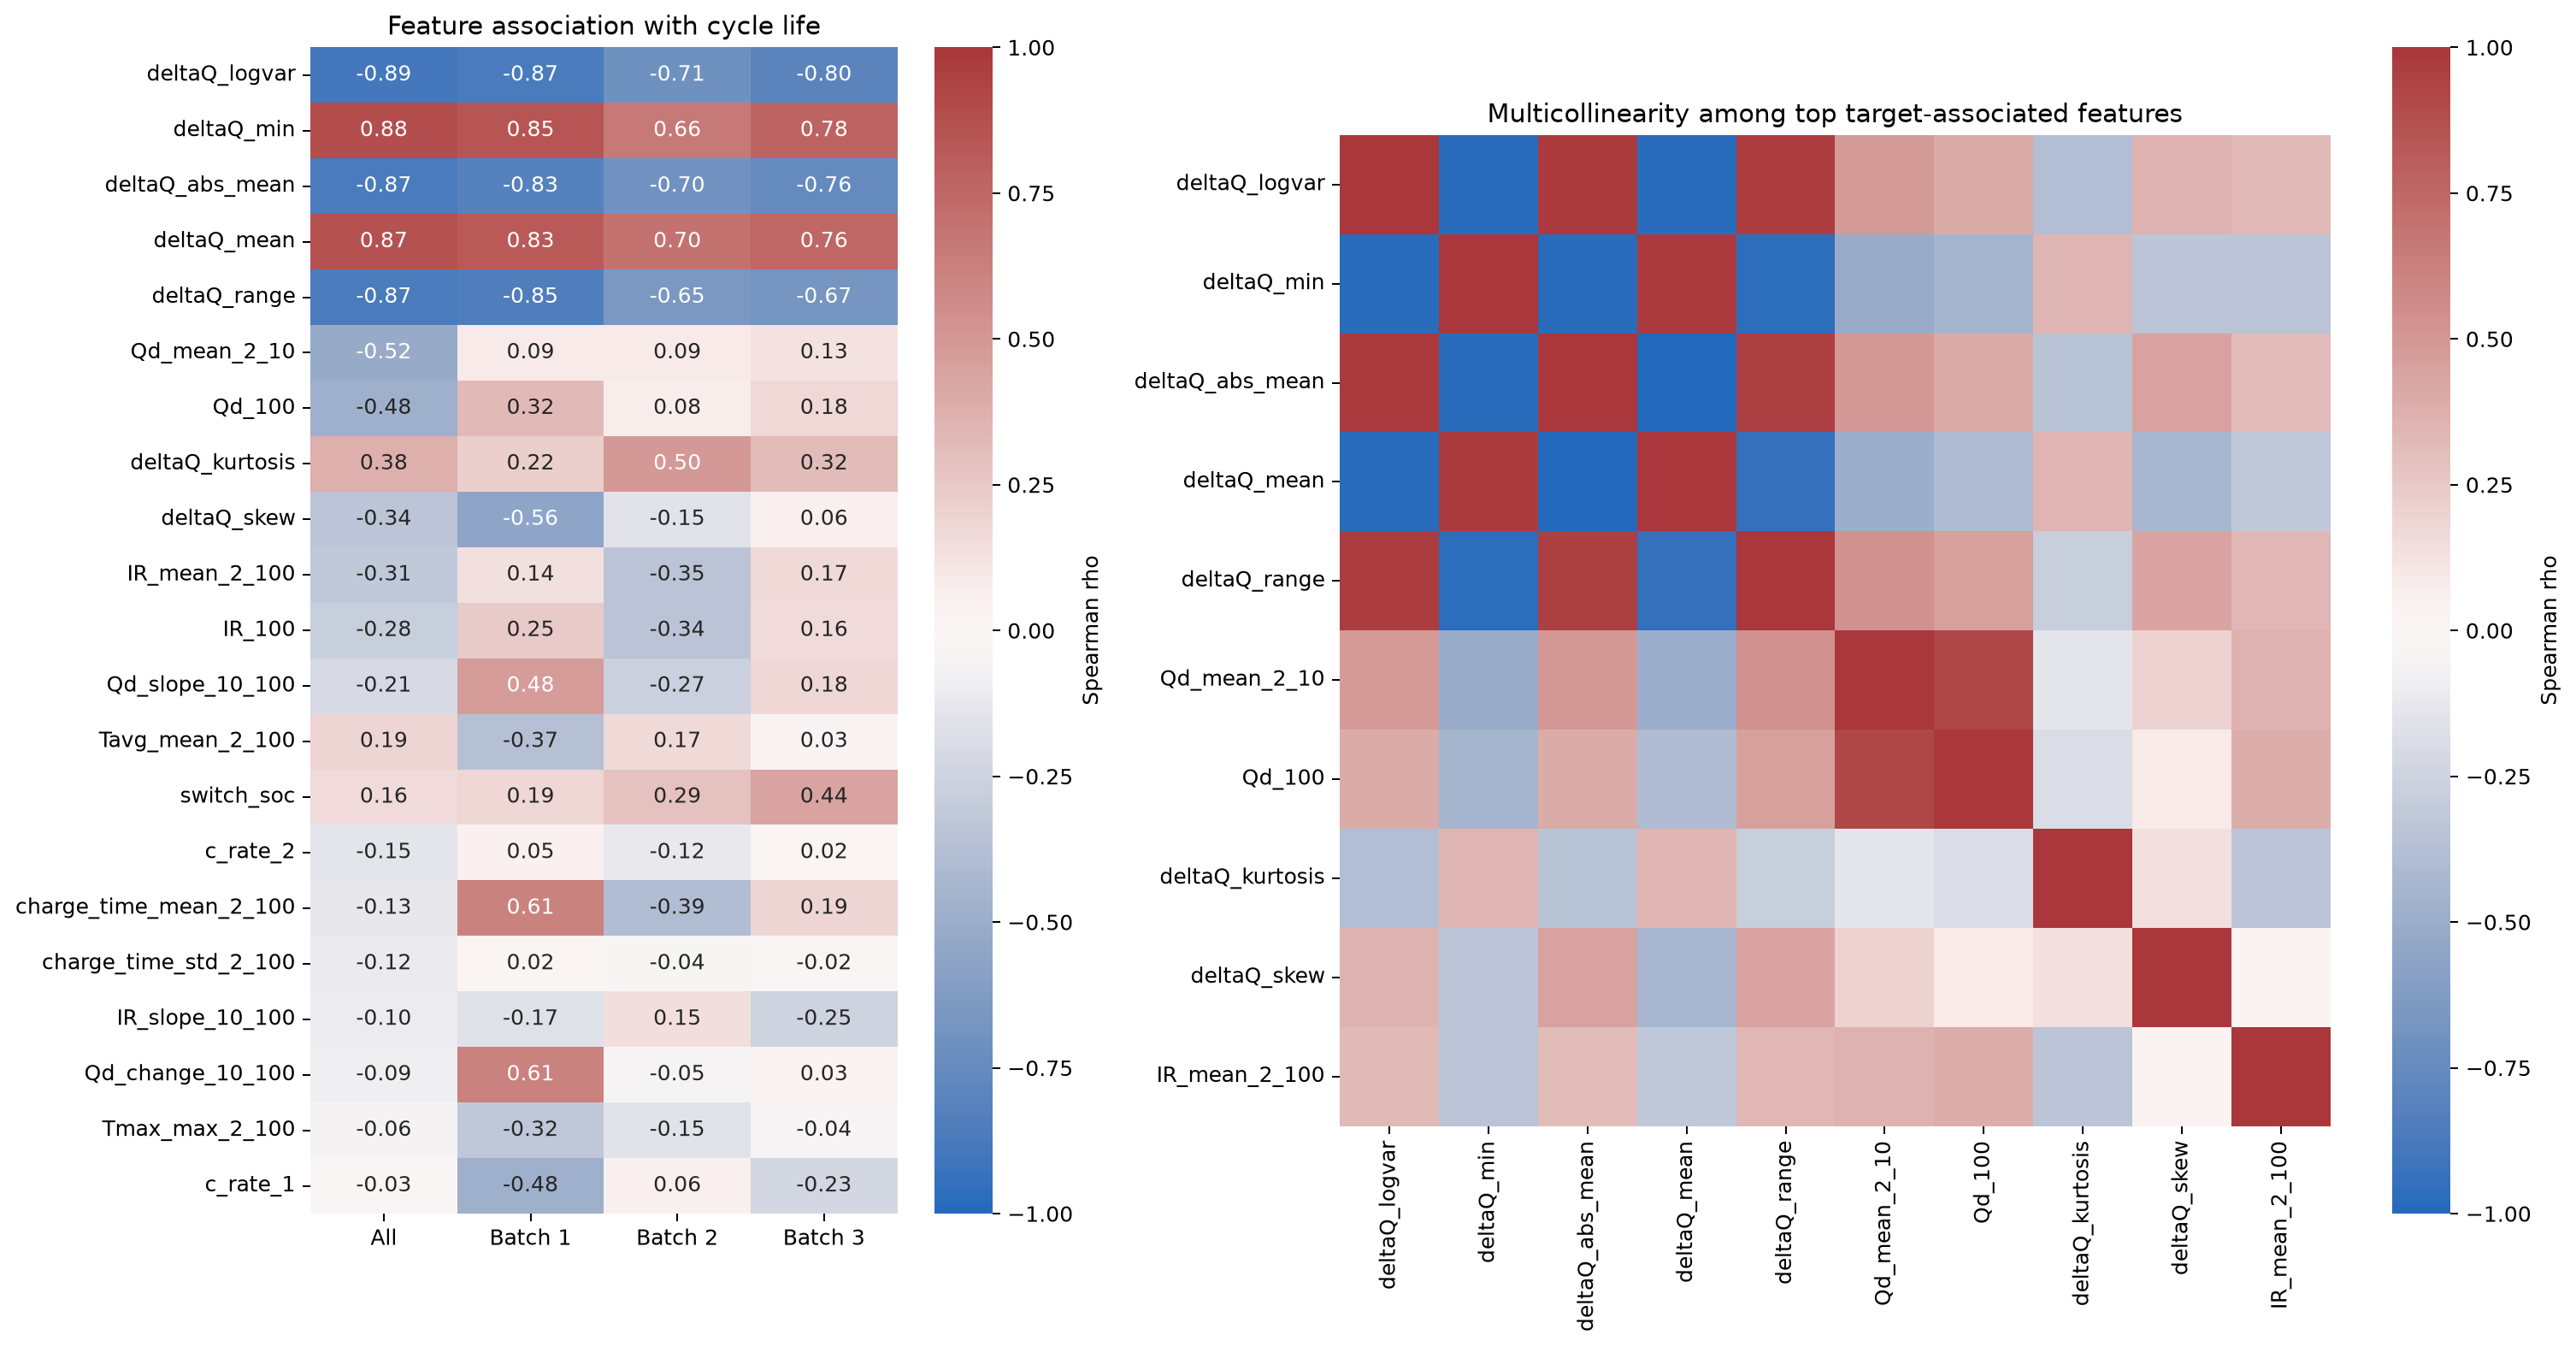

,feature,VIF
6,deltaQ_min,17.282
7,deltaQ_logvar,15.563
0,Qd_mean_2_10,2.382
11,c_rate_2,2.245
9,c_rate_1,2.173
10,switch_soc,1.584
4,Tavg_mean_2_100,1.554
1,Qd_change_10_100,1.484
5,charge_time_mean_2_100,1.321
8,deltaQ_skew,1.291


In [16]:
corr_fig = eda.plot_correlations(df, corr_long)
display(Image(filename=str(corr_fig)))

vif_columns = [
    'Qd_mean_2_10', 'Qd_change_10_100', 'IR_mean_2_100', 'IR_slope_10_100',
    'Tavg_mean_2_100', 'charge_time_mean_2_100', 'deltaQ_min',
    'deltaQ_logvar', 'deltaQ_skew', 'c_rate_1', 'switch_soc', 'c_rate_2'
]
vif = eda.compute_vif(labeled, vif_columns)
display(vif)

**해석**

- 전체 데이터에서 `Qd_mean_2_10`은 수명과 음의 상관처럼 보이지만 각 배치 내부에서는 관계가 약하거나 반대입니다. 이는 batch shift가 pooled 상관을 왜곡하는 대표 사례입니다.
- `deltaQ_min`과 `deltaQ_logvar`의 VIF가 10을 넘으므로, 비정규화 선형모델에 둘을 그대로 넣으면 계수가 불안정할 수 있습니다. Elastic Net 또는 특징 선택을 권장합니다.

## 최종 모델 설계 전략

### 선택: Regression

- **입력:** 초기 100사이클의 ΔQ(V), Qd, IR, 온도, 충전시간 및 충전정책 특징
- **Target:** `cycle_life`
- **Train/Valid:** Batch 1 내부 CV와 셀·프로토콜 단위 hold-out
- **Test:** Batch 2 최종 평가
- **Additional:** Batch 3 외부 검증
- **모델 후보:** 중앙값 baseline → Elastic Net → Random Forest/Gradient Boosting
- **평가:** MAPE 필수, MAE·RMSE·R² 보조, Train–Valid·Valid–Test·Target–Test gap 보고

Binary classification은 Batch 1에서 550사이클 미만 셀이 1개뿐이므로 현재 과제 분할에서 학습이 안정적이지 않습니다.

## 분석 데이터 저장

아래 셀은 노트북에서 추출한 셀 단위 특징과 요약표를 같은 폴더에 저장합니다.

In [17]:
df.to_csv(RESULTS_DIR / 'cell_features.csv', index=False)
summary.to_csv(RESULTS_DIR / 'batch_summary.csv', index=False)
corr_long.to_csv(RESULTS_DIR / 'feature_correlations.csv', index=False)
vif.to_csv(RESULTS_DIR / 'vif.csv', index=False)
unlabeled.to_csv(RESULTS_DIR / 'unlabeled_cells.csv', index=False)
print('저장 완료:', RESULTS_DIR)

저장 완료: /Users/jungseungwoo/Desktop/data-mini-project/results/battery_eda
